# Applied Data Science and Machine Intelligence
## A program by IIT Madras and TalentSprint
### Mini Project: Image classification using MLP and CNN



## Learning Objectives

At the end of the experiment, you will be able to :

* load and extract features of images

* implement the Multi-Layer perceptron to classify images

* implement CNN using keras

## Introduction

Traffic sign recognition is a challenging, real-world problem relevant for AI based transportation systems. Traffic signs show a wide range of variations between classes in terms of color, shape, and the presence of pictograms or text. However, there exist subsets of
classes (e.g., speed limit signs) that are very similar to each other. Further, the classifier
has to be robust against large variations in visual appearances due to changes in illumination, partial
occlusions, rotations, weather conditions etc. Using a comprehensive traffic sign detection dataset, here we will perform classification of traffic signs, train and evaluate the different models and compare to the performance of MLPs.

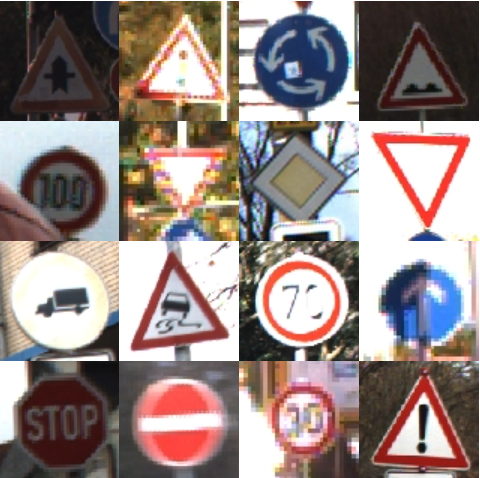

## Dataset

The data for this mini-project is from the German Traffic Sign Detection Benchmark [GTSDB](https://benchmark.ini.rub.de/gtsdb_dataset.html). This archive contains the training set used during the IJCNN 2013 competition.

The German Traffic Sign Detection Benchmark is a single-image detection assessment for researchers with interest in the field of computer vision, pattern recognition and image-based driver assistance. It is introduced on the IEEE International Joint Conference on Neural Networks 2013.

It features ...

* The main archive FullIJCNN2013.zip includes the images (1360 x 800 pixels) in PPM format, the image sections containing only the traffic signs
* A file in CSV format with the ground truth
* A ReadMe.txt with more details.

## Problem Statement

To build and improve upon a machine learning model for the classification of images and achieve a high accuracy final model.

## Grading = 10 Points

In [ ]:
#@title Download the data
!wget -qq https://sid.erda.dk/public/archives/ff17dc924eba88d5d01a807357d6614c/FullIJCNN2013.zip
!unzip -qq FullIJCNN2013.zip

### Import Required packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from skimage.io import imread, imshow
from sklearn import preprocessing
import os, glob
from PIL import Image
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Keras
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
import cv2
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.utils.class_weight import compute_class_weight


###**Excercise 1**

### Data Loading and Feature Extraction (1 points)

#### Get the features and labels of data

* Extract the features of the images
* Extract labels of the images
* Resize the images to (30, 30) and convert to numpy 1-D array

   Hint: [Link](https://machinelearningmastery.com/how-to-load-and-manipulate-images-for-deep-learning-in-python-with-pil-pillow/)

In [ ]:
# A function to read the individual folders for classes and then read them using CV and PIL.
path = "../content/FullIJCNN2013"
images=[]
labels=[]
images_1D=[]
img_dict={}
count=0
folders=[f for f in os.listdir(path) if os.path.isdir(os.path.join(path,f))]   ## Get a list of all the 43 classes and images to read through.
print(len(folders))                                                                  ## 43 folders one per each class.

#Reading the folders and the images inside.
#for folder in folders:

for folder in folders:
  #print(folder)
  img_folder=os.path.join(path,folder)
  #print(img_folder)
  for img in os.listdir(img_folder):
    img_path=os.path.join(img_folder,img)
    image=Image.open(img_path)                                       ## Reading the image using PIL library.
    image = image.resize((30, 30))                                   ## Resizing the image to 30*30.
    image=np.array(image)                                            ## Converting to an array.
    images.append(np.array(image))                                   ## Appending the resized and normalized array of the image to the list.
    image_1D=image.flatten()                                         ## Flattening the array to make it 1D for the MLP model.
    images_1D.append(image_1D)
    labels.append(int(folder))                                       ## Appending labels to the list.
    count=count+1

print(len(images))
print(len(labels))
print(len(images_1D))

## Converting list of images and labels to an array
arr_images=np.array(images)
arr_labels=np.array(labels)
arr_images_1D=np.array(images_1D)
print(count)

43
1213
1213
1213
1213


In [ ]:
##Checking the size of each array

print(arr_images.shape)                                            ## (1213, 30, 30, 3)
print(arr_labels.shape)                                            ## (1213,)
print(arr_images_1D.shape)                                         ## (1213, 2700)


(1213, 30, 30, 3)
(1213,)
(1213, 2700)


###**Excercise 2**
### Data Exploration and Preprocessing ( 2 points)

#### Plot the sample image of each class

Hint: plt.subplot

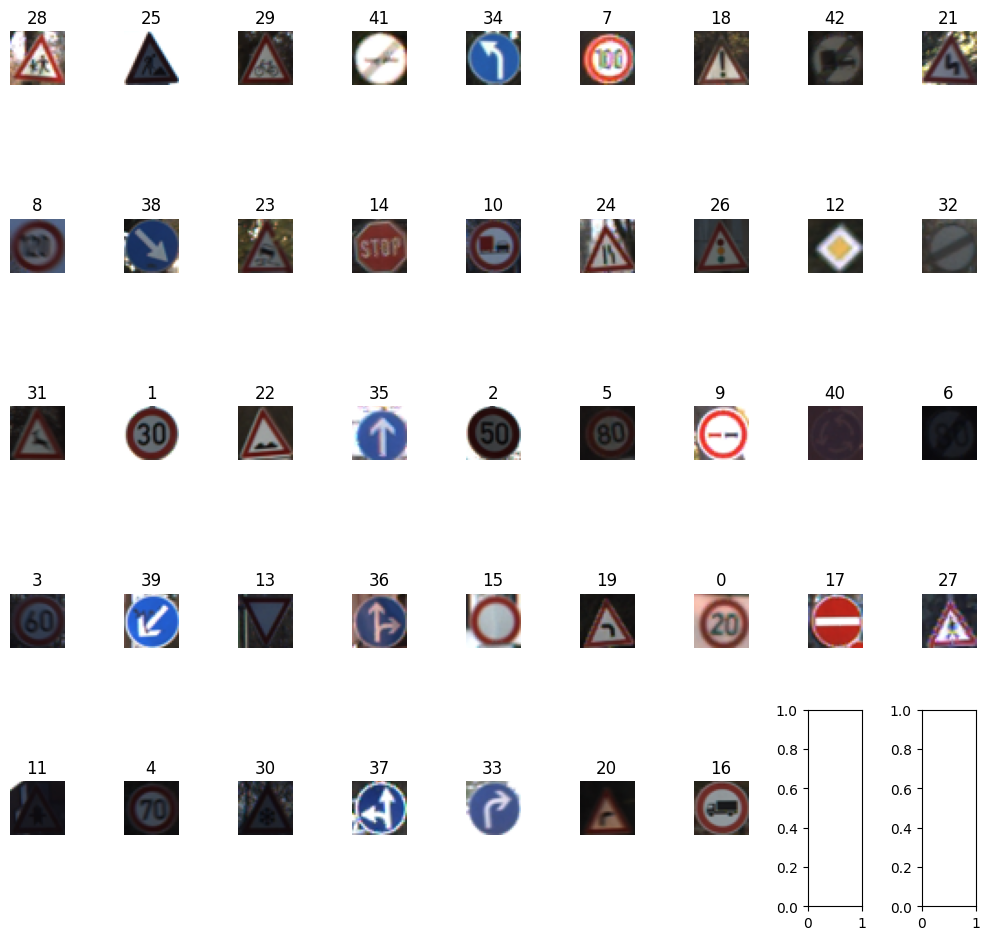

In [ ]:
# Visualising the class samples
fig,axes = plt.subplots(5,9,figsize=(10,10))
uniq_label=[]
j=0
for index,label in enumerate(arr_labels):
  if label not in uniq_label:
    uniq_label.append(label)
    ax=axes.flatten()
    ax[j].imshow(arr_images[index])
    ax[j].set_title(label)
    ax[j].axis("off")
    j=j+1

plt.tight_layout()
plt.show()





#### Plot the distribution of Classes

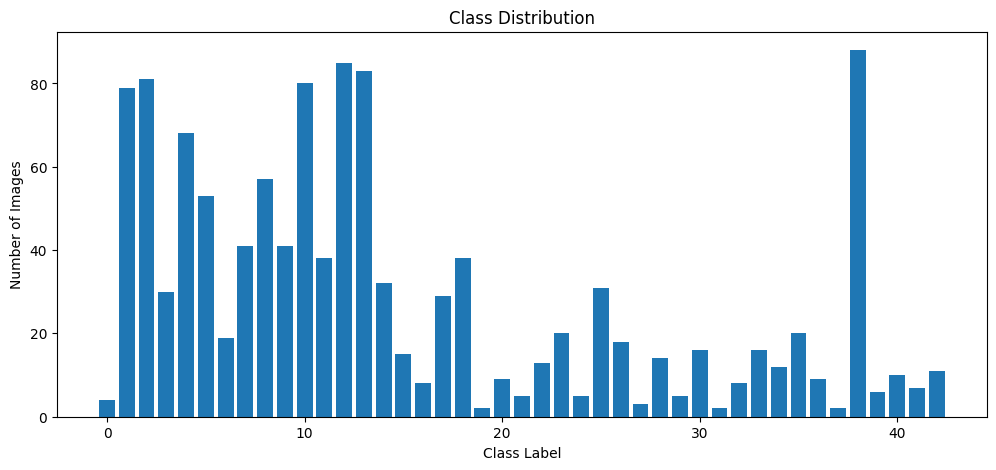

In [ ]:
#Plot the distribution of classes.
counts = np.bincount(arr_labels)                #getting the count of each class.
plt.figure(figsize=(12,5))
plt.bar(range(len(counts)), counts)
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

In [ ]:
counts

array([ 4, 79, 81, 30, 68, 53, 19, 41, 57, 41, 80, 38, 85, 83, 32, 15,  8,
       29, 38,  2,  9,  5, 13, 20,  5, 31, 18,  3, 14,  5, 16,  2,  8, 16,
       12, 20,  9,  2, 88,  6, 10,  7, 11])

#### Normalize the features

For most image data, the pixel values are integers with values between 0 and 255.

Neural networks process inputs using small weight values, and inputs with large integer values can disrupt or slow down the learning process. As such it is good practice to normalize the pixel values.

Hint: sklearn.preprocessing.normalize

In [ ]:
#normalizing the flattened image for the MLP model.
def normalize_image_mlp(arr_images_1D):
  arr_images_1D_norm=normalize(arr_images_1D,norm='l2')                            # l2 norm normalization of the 1D flattened array created earlier.
  return arr_images_1D_norm
#calling the function to normalize the flattened array.
arr_images_1D_norm=normalize_image_mlp(arr_images_1D)
#print(arr_images_1D_norm.shape)                                                     #Retains the original shape.
#print(arr_images_1D_norm[0])                                                        #sample of the normalized data between 0 to 1 from 0 to 255.
#normalizing the input for the CNN model
def normalize_image_cnn(arr_images):
  arr_images_norm=arr_images/255.0
  return arr_images_norm
arr_images_norm=normalize_image_cnn(arr_images)
#print(arr_images_norm.shape)                                                         #Retains the original shape, (1213,30,30,3)
#print(arr_images_norm[0])                                                            #Sample of the normalized data between 0 to 1 from 0 to 255.


In [ ]:
## Now we have the preprocessed images for both MLP and CNN models we can use them to split into train, validation and test data sets.
#Before that lets list down our final arrays to be used for each of the models.

## Input arrays for the MLP model####
arr_images_1D_norm                                                                            ##(1213,2700)
# Input arrays for the CNN model ####
arr_images_norm                                                                               ## (1213,30,30,3)

## Class labels to be used.
arr_labels                                                                                   ## (1213,)

array([28, 28, 28, ..., 16, 16, 16])

###**Excercise 3**
### Train the MLP classifier on features (3 points)

* Split the data into train and test

* Train the MLP classifier with different parameters

* Get the accuracy score and performance metrics



* Define the keras model and initialize the layers
  - Ensure the input layer has the right number of input features. This can be specified when creating the first layer with the input_dim argument.
* Compile the model
  - Specify the loss function (to evaluate a set of weights), the optimizer (is used to search through different weights for the network) and any optional metrics to collect and report during training.
* Fit and Evaluate the model
  - Fit the data by specifying epochs and evaluate the model

In [ ]:
### test, validate, train for MLP.
##Splitting the data into Train, validation and test
X_train_mlp, X_temp_mlp, y_train_mlp, y_temp_mlp = train_test_split(
    arr_images_1D_norm,
    arr_labels ,
    test_size=0.2,
    stratify=arr_labels,
    random_state=42
)
X_val_mlp, X_test_mlp, y_val_mlp, y_test_mlp = train_test_split(
    X_temp_mlp,
    y_temp_mlp,
    test_size=0.5,
    #stratify=y_temp_mlp,
    random_state=42
)

#Verifying the shapes after split
print(X_train_mlp.shape)
print(X_val_mlp.shape)
print(X_test_mlp.shape)
print(y_train_mlp.shape)
print(y_val_mlp.shape)
print(y_test_mlp.shape)

(970, 2700)
(121, 2700)
(122, 2700)
(970,)
(121,)
(122,)


In [ ]:
## Due to the class Imbalance we should also use class weights for the model to not to ignore the classes with less population.
classes= np.unique(y_train_mlp)
weights =compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_mlp
)

class_weights=dict(zip(classes, weights))

In [ ]:
# Step 1 - Build the architecture
# We are preparing an MLP with 3 Dense layers each followed by a dropout layer. The Dense layers we are gradually reducing the neurons
model_mlp=keras.models.Sequential()
model_mlp.add(keras.layers.Dense(1024,activation='relu',input_shape=(2700,)))
model_mlp.add(keras.layers.Dropout(0.5))

model_mlp.add(keras.layers.Dense(512,activation='relu'))
model_mlp.add(keras.layers.Dropout(0.4))

model_mlp.add(keras.layers.Dense(256,activation='relu'))
model_mlp.add(keras.layers.Dropout(0.3))

model_mlp.add(keras.layers.Dense(43,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     2,765,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,433,003 (13.10 MB)

 Trainable params: 3,433,003 (13.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 2 - Compile the model    #We are using adam optimizer and sparse categorical entropy as loss function.
model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 3 - Fit and Evaluate the model
history=model_mlp.fit(
    X_train_mlp,
    y_train_mlp,
    validation_data=(X_val_mlp,y_val_mlp),
    epochs=40,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.0275 - loss: 3.7273 - val_accuracy: 0.1157 - val_loss: 3.6894
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.0337 - loss: 3.6394 - val_accuracy: 0.0331 - val_loss: 3.7335
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.0319 - loss: 3.6563 - val_accuracy: 0.0579 - val_loss: 3.7345
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0252 - loss: 3.9309 - val_accuracy: 0.0000e+00 - val_loss: 3.7566
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.0220 - loss: 3.7240 - val_accuracy: 0.0496 - val_loss: 3.7162
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.0546 - loss: 3.7579 - val_accuracy: 0.0661 - val_loss: 3.6896
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0574 - loss: 3.5803 - val_accuracy: 0.0579 - val_loss: 3.7015
Epoch 8/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0397 - loss: 3.4724 - val_accuracy: 0.0826

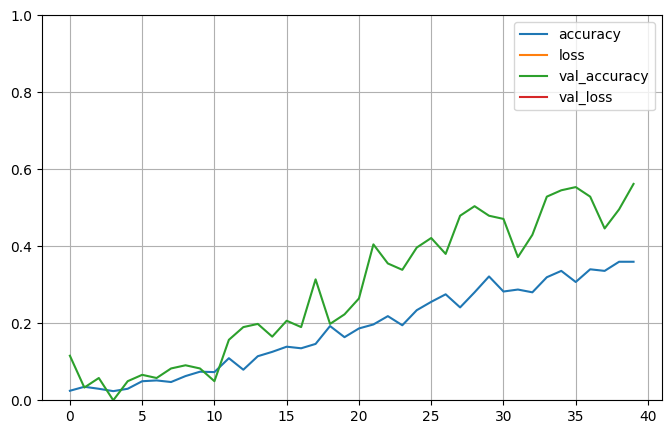

In [ ]:
## Plotting the training and validation accuracy.
df = pd.DataFrame(history.history)
df.plot(figsize=(8, 5))
plt.grid(True)
# set the vertical range to [0-1]
plt.gca().set_ylim(0, 1)
plt.show()


In [ ]:
## Evaluating the model on the test data
y_pred_probs=model_mlp.predict(X_test_mlp)                                    #Returns an array of probablity distributed over 43 classes for all the 122 samples.
y_pred=np.argmax(y_pred_probs,axis=1)                                         # picking up the class with high


print("Test Accuracy:", accuracy_score(y_test_mlp, y_pred))
print(classification_report(y_test_mlp,y_pred,zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Test Accuracy: 0.45081967213114754
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.20      0.29        10
           2       0.25      0.14      0.18         7
           3       0.00      0.00      0.00         2
           4       1.00      0.50      0.67         4
           5       1.00      0.29      0.44         7
           6       0.00      0.00      0.00         1
           7       0.29      1.00      0.44         4
           8       0.00      0.00      0.00         5
           9       0.40      0.50      0.44         4
          10       0.25      0.18      0.21        11
          11       0.75      0.75      0.75         4
          12       1.00      0.50      0.67        10
          13       1.00      0.80      0.89         5
          14       1.00      1.00      1.00         2
          15       0.33      1.00      0.50         2
        

In [ ]:
# #print confusion matrix

# cm = confusion_matrix(y_test_mlp, y_pred)

# plt.figure(figsize=(10,8))
# sns.heatmap(cm, cmap="Blues")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix - MLP")
# plt.show()


In [ ]:
#Printing the prediction for one image
img=X_test_mlp[0:1]
img1=X_test_mlp[2:4]                                                       #original label 11
prediction = model_mlp.predict(img)
prediction1 = model_mlp.predict(img1)
predicted_class_img = np.argmax(prediction)
predicted_class_img1_1 = np.argmax(prediction1[0])                        #original label 23
predicted_class_img1_2 = np.argmax(prediction1[1])                        #original label 13

print(predicted_class_img)                                                #predicted class 11
print(predicted_class_img1_1)                                             #predicted call  28
print(predicted_class_img1_2)                                             #preidcted class 13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
11
24
13


#### Try the different algorithms and compare the results with MLP classifier

###**Excercise 4**
### Train a CNN classifier on images (4 points)

* Split the data into train and test

* Train the CNN with 2D convolution and Maxpooling layers

* Get the accuracy score on train and test sets



* Define the keras model and initialize the layers
  - Ensure the input layer is specified with correct image size as input. This can be specified when creating the first layer with the input_shape argument.
* Speicify number of filters Kernel size, Pool size and activation function
  - filters,kernel_size and activation arguments of Conv2D layer can be used
  - pool_size argument of MaxPool2D can be used to set Pool size
* Compile the model
  - Specify the loss function (to evaluate a set of weights), the optimizer (is used to search through different weights for the network) and any optional metrics to collect and report during training.
* Fit and Evaluate the model
  - Fit the data by specifying epochs and evaluate the model

In [ ]:
#Split the dataset into train test and validation datasets
X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(
    arr_images_norm,
    arr_labels ,
    test_size=0.2,
    stratify=arr_labels,
    random_state=42
)
X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(
    X_temp_cnn,
    y_temp_cnn,
    test_size=0.5,
    #stratify=y_temp_mlp,
    random_state=42
)

#Verifying the shapes after split
print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)
print(y_train_cnn.shape)
print(y_val_cnn.shape)
print(y_test_cnn.shape)

(970, 30, 30, 3)
(121, 30, 30, 3)
(122, 30, 30, 3)
(970,)
(121,)
(122,)


In [ ]:
# Step 1 - Build the architecture
model_cnn=keras.models.Sequential()
model_cnn.add(keras.layers.Conv2D(32,(3,3),activation='relu', input_shape=(30,30,3)))              #Input Layer
model_cnn.add(keras.layers.MaxPooling2D((2,2)))                                                    #MaxPooling to take the import features #reduces the size of the array

#Another CNN Layer
model_cnn.add(keras.layers.Conv2D(64,(3,3),activation='relu'))              #Input Layer
model_cnn.add(keras.layers.MaxPooling2D((2,2)))

#Another CNN Layer
model_cnn.add(keras.layers.Conv2D(128,(3,3),activation='relu'))

#Flatten the model to add the Dense layer
model_cnn.add(keras.layers.Flatten())

#Add another dense layer with 64 neurons
model_cnn.add(keras.layers.Dense(128, activation='relu'))

# Adding the final classification layer (43 classes)
model_cnn.add(keras.layers.Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 2 - Compile the model
model_cnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 3 - Fit and Evaluate the model
history_cnn=model_cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn,y_val_cnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.0227 - loss: 3.7805 - val_accuracy: 0.0909 - val_loss: 3.7394
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0504 - loss: 3.6166 - val_accuracy: 0.0909 - val_loss: 3.6447
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.0890 - loss: 3.7012 - val_accuracy: 0.1653 - val_loss: 3.3750
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.1704 - loss: 3.0699 - val_accuracy: 0.3554 - val_loss: 2.6504
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.3326 - loss: 2.4962 - val_accuracy: 0.3967 - val_loss: 2.3440
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.4392 - loss: 1.9933 - val_accuracy: 0.5868 - val_loss: 1.6475
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5907 - loss: 1.5068 - val_accuracy: 0.6198 - val_loss: 1.4067
Epoch 8/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6045 - loss: 1.1787 - val_accuracy: 0.7686 - 

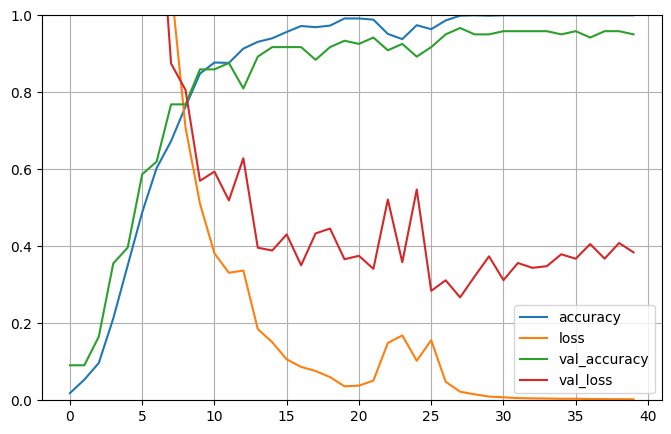

In [ ]:
## Plotting the training and validation accuracy.
df_cnn = pd.DataFrame(history_cnn.history)
df_cnn.plot(figsize=(8, 5))
plt.grid(True)
# set the vertical range to [0-1]
plt.gca().set_ylim(0, 1)
plt.show()


In [ ]:
## Evaluating the model on the test data
y_pred_probs_cnn=model_cnn.predict(X_test_cnn)                                    #Returns an array of probablity distributed over 43 classes for all the 122 samples.
y_pred_cnn=np.argmax(y_pred_probs_cnn,axis=1)                                         # picking up the class with high


print("Test Accuracy:", accuracy_score(y_test_cnn, y_pred_cnn))
print(classification_report(y_test_cnn,y_pred_cnn,zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Test Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.90      0.90      0.90        10
           2       1.00      0.86      0.92         7
           3       0.67      1.00      0.80         2
           4       0.80      1.00      0.89         4
           5       0.86      0.86      0.86         7
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         5
           9       0.80      1.00      0.89         4
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00         4
          12       1.00      0.80      0.89        10
          13       1.00      0.80      0.89         5
          14       1.00      1.00      1.00         2
          15       0.67      1.00      0.80         2
         

In [ ]:
#Printing the prediction for one image
img=X_test_cnn[0:1]
img1=X_test_cnn[2:4]                                                       #original label 11
prediction = model_cnn.predict(img)
prediction1 = model_cnn.predict(img1)
predicted_class_img = np.argmax(prediction)
predicted_class_img1_1 = np.argmax(prediction1[0])                        #original label 23
predicted_class_img1_2 = np.argmax(prediction1[1])                        #original label 13

print(predicted_class_img)                                                #predicted class 11
print(predicted_class_img1_1)                                             #predicted call  20
print(predicted_class_img1_2)                                             #preidcted class 13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
11
23
13


##Variations Adding Droput and Batch Normalisation Layers and using padding as same.

In [ ]:
##Variations Adding Dropout and Batch Normalization.
model_cnn = keras.models.Sequential()

model_cnn.add(keras.layers.Conv2D(32,(3,3),padding='same',activation='relu', input_shape=(30,30,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.MaxPooling2D((2,2)))
model_cnn.add(keras.layers.Dropout(0.25))

model_cnn.add(keras.layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.MaxPooling2D((2,2)))
model_cnn.add(keras.layers.Dropout(0.25))

model_cnn.add(keras.layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model_cnn.add(keras.layers.BatchNormalization())

model_cnn.add(keras.layers.Flatten())

model_cnn.add(keras.layers.Dense(128, activation='relu'))
model_cnn.add(keras.layers.Dropout(0.5))

model_cnn.add(keras.layers.Dense(43, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 2 - Compile the model
model_cnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902,635 (3.44 MB)

 Trainable params: 902,187 (3.44 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Step 3 - Fit and Evaluate the model
history_cnn=model_cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn,y_val_cnn),
    epochs=20,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.8919 - loss: 0.3117 - val_accuracy: 0.8926 - val_loss: 0.5054
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.8540 - loss: 0.4749 - val_accuracy: 0.9504 - val_loss: 0.1505
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9034 - loss: 0.2493 - val_accuracy: 0.9339 - val_loss: 0.2236
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8804 - loss: 0.3692 - val_accuracy: 0.9256 - val_loss: 0.2028
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.8477 - loss: 0.5542 - val_accuracy: 0.9587 - val_loss: 0.2334
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8988 - loss: 0.3361 - val_accuracy: 0.9421 - val_loss: 0.2208
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.9189 - loss: 0.2175 - val_accuracy: 0.9752 - val_loss: 0.0940
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9525 - loss: 0.1073 - val_accuracy: 0.9

In [ ]:
## Evaluating the model on the test data
y_pred_probs_cnn=model_cnn.predict(X_test_cnn)                                    #Returns an array of probablity distributed over 43 classes for all the 122 samples.
y_pred_cnn=np.argmax(y_pred_probs_cnn,axis=1)                                         # picking up the class with high


print("Test Accuracy:", accuracy_score(y_test_cnn, y_pred_cnn))
print(classification_report(y_test_cnn,y_pred_cnn,zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.62      1.00      0.77        10
           2       0.83      0.71      0.77         7
           3       1.00      1.00      1.00         2
           4       1.00      0.25      0.40         4
           5       1.00      0.86      0.92         7
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         4
          10       1.00      0.91      0.95        11
          11       1.00      1.00      1.00         4
          12       0.91      1.00      0.95        10
          13       1.00      0.80      0.89         5
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
         

Adding the Augmentation layer to train the model on different variations of the image

In [ ]:
#Creating the Augmentation model, we can do using ImageGenerator module as in one assignment. each epoch is new set of data. For ex: with 30 epochs it will be 1213*30
data_augmentation = keras.models.Sequential()
data_augmentation.add(keras.layers.RandomRotation(0.1))
data_augmentation.add(keras.layers.RandomZoom(0.1)),
data_augmentation.add(keras.layers.RandomTranslation(0.1, 0.1)),
data_augmentation.add(keras.layers.RandomBrightness(0.2)),


(None,)

In [ ]:
#Adding the augmentation layer to the cnn architecture above. Here we train accros
model_cnn = keras.models.Sequential()

data_augmentation,                                                                                                        ##created augmentation layer gets added before input layer so the image gets transformed before input.
model_cnn.add(keras.layers.Conv2D(32,(3,3),padding='same',activation='relu', input_shape=(30,30,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.MaxPooling2D((2,2)))
model_cnn.add(keras.layers.Dropout(0.25))

model_cnn.add(keras.layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.MaxPooling2D((2,2)))
model_cnn.add(keras.layers.Dropout(0.25))

model_cnn.add(keras.layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model_cnn.add(keras.layers.BatchNormalization())

model_cnn.add(keras.layers.Flatten())

model_cnn.add(keras.layers.Dense(128, activation='relu'))
model_cnn.add(keras.layers.Dropout(0.5))

model_cnn.add(keras.layers.Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 2 - Compile the model
model_cnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902,635 (3.44 MB)

 Trainable params: 902,187 (3.44 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Step 3 - Fit and Evaluate the model
history_cnn=model_cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn,y_val_cnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.0555 - loss: 4.5281 - val_accuracy: 0.0661 - val_loss: 3.7316
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.1599 - loss: 3.0718 - val_accuracy: 0.0083 - val_loss: 3.9268
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.2291 - loss: 3.0405 - val_accuracy: 0.0248 - val_loss: 4.8991
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.3249 - loss: 2.4928 - val_accuracy: 0.0413 - val_loss: 6.3215
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4012 - loss: 2.4991 - val_accuracy: 0.0744 - val_loss: 6.7011
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4808 - loss: 1.8668 - val_accuracy: 0.1570 - val_loss: 6.4339
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.5254 - loss: 1.9554 - val_accuracy: 0.0992 - val_loss: 9.2126
Epoch 8/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.5095 - loss: 1.5319 - val_accuracy: 0.

In [ ]:
## Evaluating the model on the test data
y_pred_probs_cnn=model_cnn.predict(X_test_cnn)                                    #Returns an array of probablity distributed over 43 classes for all the 122 samples.
y_pred_cnn=np.argmax(y_pred_probs_cnn,axis=1)                                         # picking up the class with high


print("Test Accuracy:", accuracy_score(y_test_cnn, y_pred_cnn))
print(classification_report(y_test_cnn,y_pred_cnn,zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
Test Accuracy: 0.9344262295081968
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.91      1.00      0.95        10
           2       1.00      0.86      0.92         7
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         7
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00         4
          12       0.91      1.00      0.95        10
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         2
          15       0.67      1.00      0.80         2
        

In [ ]:
#Using transfer learning
